#  Temporal Analysis 

**The Big Idea**: So far we analyzed WHAT events happen and in WHAT ORDER. Now we add WHEN. 

Time reveals things that sequence alone can't:
- Do failures cluster at certain times? (Burst patterns)
- Are anomaly traces faster or slower than normal ones? (Latency signals)
- Do the gaps between events differ in anomalies? (Timing fingerprints)
- Can we spot the exact moment a system starts degrading? (Trend detection)



**Data sources**:
- `HDFS.log` — raw timestamps (format: `YYMMDD HHMMSS`)
- `Event_traces.csv` — `TimeInterval` (gaps between events) and `Latency` (total trace duration)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
from collections import Counter
import ast
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

DATA_DIR = "../../preprocessed"
RAW_LOG = "../../HDFS.log"


traces_df = pd.read_csv(os.path.join(DATA_DIR, "Event_traces.csv"))


normal_traces = traces_df[traces_df['Label'] == 'Success']
anomaly_traces = traces_df[traces_df['Label'] == 'Fail']

print(f"✅ Loaded {traces_df.shape[0]:,} traces")


✅ Loaded 575,061 traces


In [ ]:
traces_df.head(10) 

,BlockId,Label,Type,Features,TimeInterval,Latency
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
2,blk_-3544583377289625738,Fail,21.0,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",3797
3,blk_-9073992586687739851,Success,NaN,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50448
4,blk_7854771516489510256,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50583
5,blk_1717858812220360316,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 11.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0...",50458
6,blk_-2519617320378473615,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 9.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50523
7,blk_7063315473424667801,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E9,E26,E26,E11,E9,E26...","[1.0, 0.0, 0.0, 58.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50818
8,blk_8586544123689943463,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E11,E9,E9,E26,E26,E26...","[1.0, 0.0, 0.0, 36.0, 0.0, 1.0, 0.0, 0.0, 0.0,...",50795
9,blk_2765344736980045501,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E26,E11,E9,E26,E26...","[0.0, 0.0, 1.0, 28.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",50528


In [ ]:
normal_traces.count()  


BlockId         558223
Label           558223
Type                 0
Features        558223
TimeInterval    558223
Latency         558223
dtype: int64

In [ ]:
anomaly_traces.count()  

BlockId         16838
Label           16838
Type            16838
Features        16838
TimeInterval    16838
Latency         16838
dtype: int64

##  Step 1: Latency 



This is the simplest temporal feature and often the most powerful. If a block takes 50 seconds when normal blocks take 4 seconds, something went very wrong — even if the event sequence LOOKS similar.




In [10]:
# Basic latency statistics
n_lat = normal_traces['Latency']
a_lat = anomaly_traces['Latency']

print(f"{'Statistic':>15} {'Normal':>12} {'Anomaly':>12} {'Ratio':>8}")
print(f"{'─'*50}")

stats = {
    'Mean': (n_lat.mean(), a_lat.mean()),
    'Median': (n_lat.median(), a_lat.median()),
    'Std Dev': (n_lat.std(), a_lat.std()),
    'Min': (n_lat.min(), a_lat.min()),
    'Max': (n_lat.max(), a_lat.max()),
    '25th %ile': (n_lat.quantile(0.25), a_lat.quantile(0.25)),
    '75th %ile': (n_lat.quantile(0.75), a_lat.quantile(0.75)),
    '95th %ile': (n_lat.quantile(0.95), a_lat.quantile(0.95)),
}

for name, (n_val, a_val) in stats.items():
    ratio = a_val / n_val if n_val > 0 else float('inf')
    print(f"{name:>15} {n_val:>12,.1f} {a_val:>12,.1f} {ratio:>7.1f}×")


      Statistic       Normal      Anomaly    Ratio
──────────────────────────────────────────────────
           Mean     16,870.9     14,089.5     0.8×
         Median      7,303.0      4,920.5     0.7×
        Std Dev     17,865.7     18,376.6     1.0×
            Min          0.0          0.0     inf×
            Max     54,025.0     53,924.0     1.0×
      25th %ile      1,241.0          3.0     0.0×
      75th %ile     33,732.0     31,717.5     0.9×
      95th %ile     50,800.9     51,205.2     1.0×


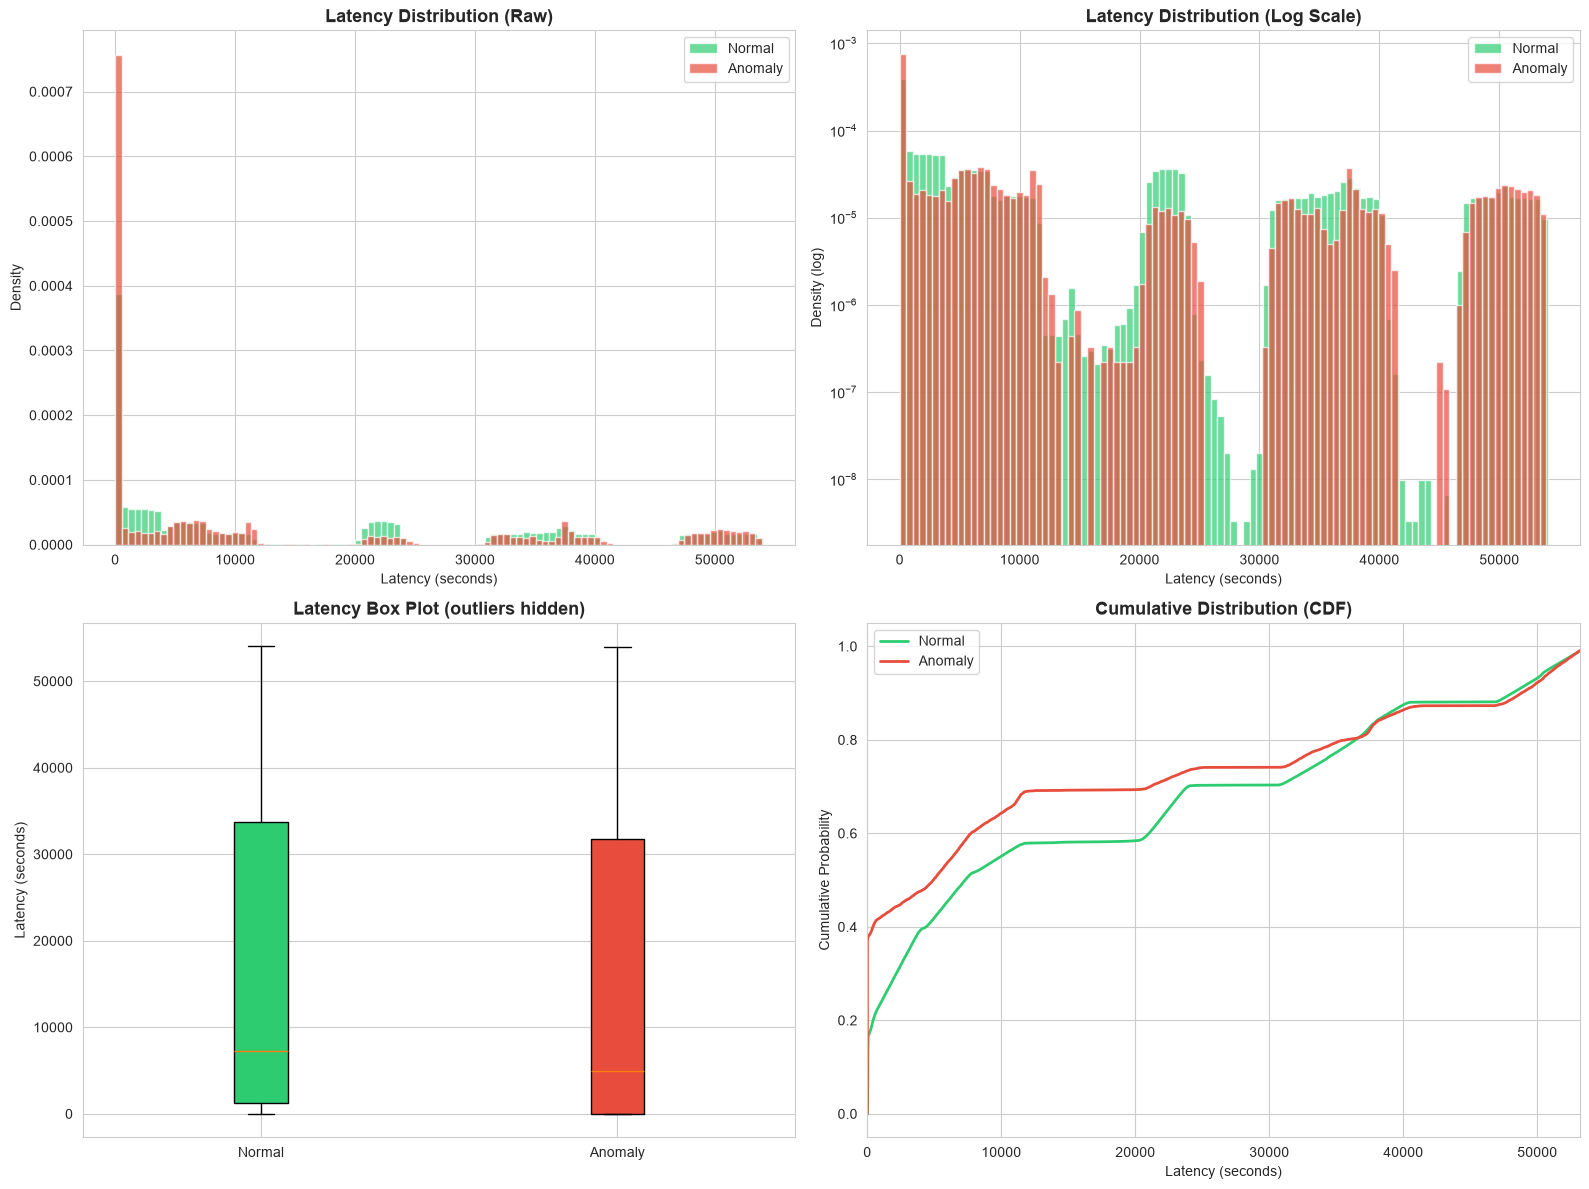

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0][0].hist(n_lat, bins=100, alpha=0.7, color='#2ecc71', label='Normal', density=True)
axes[0][0].hist(a_lat, bins=100, alpha=0.7, color='#e74c3c', label='Anomaly', density=True)
axes[0][0].set_title('Latency Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0][0].set_xlabel('Latency (seconds)')
axes[0][0].set_ylabel('Density')
axes[0][0].legend()


axes[0][1].hist(n_lat, bins=100, alpha=0.7, color='#2ecc71', label='Normal', density=True)
axes[0][1].hist(a_lat, bins=100, alpha=0.7, color='#e74c3c', label='Anomaly', density=True)
axes[0][1].set_title('Latency Distribution (Log Scale)', fontsize=13, fontweight='bold')
axes[0][1].set_xlabel('Latency (seconds)')
axes[0][1].set_ylabel('Density (log)')
axes[0][1].set_yscale('log')
axes[0][1].legend()

box_data = [n_lat.values, a_lat.values]

bp = axes[1][0].boxplot(
    box_data,
    tick_labels=['Normal', 'Anomaly'],
    patch_artist=True,
    showfliers=False      # Hide outliers
)

bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')

axes[1][0].set_title(
    'Latency Box Plot (outliers hidden)',
    fontsize=13,
    fontweight='bold'
)

axes[1][0].set_ylabel('Latency (seconds)')


for data, color, label in [(n_lat, '#2ecc71', 'Normal'), (a_lat, '#e74c3c', 'Anomaly')]:
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    axes[1][1].plot(sorted_data, cdf, color=color, label=label, linewidth=2)
axes[1][1].set_title('Cumulative Distribution (CDF)', fontsize=13, fontweight='bold')
axes[1][1].set_xlabel('Latency (seconds)')
axes[1][1].set_ylabel('Cumulative Probability')
axes[1][1].legend()
axes[1][1].set_xlim(0, n_lat.quantile(0.99))  # Zoom to 99th percentile

plt.tight_layout()
plt.savefig('../outputs/latency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


**Early latency (0–12k)**

The red curve is consistently above the green.

This tells us

Anomalies tend to have smaller latency values more frequently than normal traffic.

**Middle latency (20k–35k)**

The curves get closer.

The difference between normal and anomaly decreases.

Latency becomes less useful for distinguishing them.

**Large latency (>38k)**

The curves almost coincide.

This indicates

Normal and anomaly behave almost the same for high latency values.

##  Step 2: Inter-Event Time Intervals

**Concept**: The `TimeInterval` column contains the time gaps (in seconds) between consecutive events within each trace. For a trace with events `[E5, E22, E5, E7]`, the time intervals might be `[0, 1, 0, 5]` — meaning:
- E5→E22: 0 seconds (happened simultaneously)
- E22→E5: 1 second gap
- E5→E7: 5 second gap (suspiciously long — was the system struggling?)

Large gaps between events suggest **delays, retries, or timeouts**. The pattern of gaps can be as diagnostic as the events themselves.


In [17]:
# Parse TimeInterval column from string to list of floats
def parse_intervals(interval_str):
    try:
        return ast.literal_eval(interval_str)
    except:
        return []

print("Parsing time intervals...")
traces_df['intervals'] = traces_df['TimeInterval'].apply(parse_intervals)
traces_df['num_intervals'] = traces_df['intervals'].apply(len)

# Compute per-trace interval statistics
traces_df['mean_interval'] = traces_df['intervals'].apply(
    lambda x: np.mean(x) if len(x) > 0 else 0)
traces_df['max_interval'] = traces_df['intervals'].apply(
    lambda x: np.max(x) if len(x) > 0 else 0)
traces_df['std_interval'] = traces_df['intervals'].apply(
    lambda x: np.std(x) if len(x) > 0 else 0)
traces_df['zero_pct'] = traces_df['intervals'].apply(
    lambda x: sum(1 for v in x if v == 0) / len(x) * 100 if len(x) > 0 else 0)

# Re-split after new columns
normal_traces = traces_df[traces_df['Label'] == 'Success']
anomaly_traces = traces_df[traces_df['Label'] == 'Fail']

print("✅ Done!")

# Compare interval statistics
print(f"\n{'Metric':>20} {'Normal':>12} {'Anomaly':>12} {'Ratio':>8}")
print(f"{'─'*55}")
for col, label in [('mean_interval', 'Mean Interval'),
                   ('max_interval', 'Max Interval'),
                   ('std_interval', 'Interval Std Dev'),
                   ('zero_pct', '% Zero Gaps')]:
    n_val = normal_traces[col].mean()
    a_val = anomaly_traces[col].mean()
    ratio = a_val / n_val if n_val > 0 else float('inf')
    print(f"{label:>20} {n_val:>12.2f} {a_val:>12.2f} {ratio:>7.1f}×")


Parsing time intervals...
✅ Done!

              Metric       Normal      Anomaly    Ratio
───────────────────────────────────────────────────────
       Mean Interval       800.72       551.83     0.7×
        Max Interval     12080.85      9198.35     0.8×
    Interval Std Dev      2778.98      1961.56     0.7×
         % Zero Gaps        65.47        62.01     0.9×


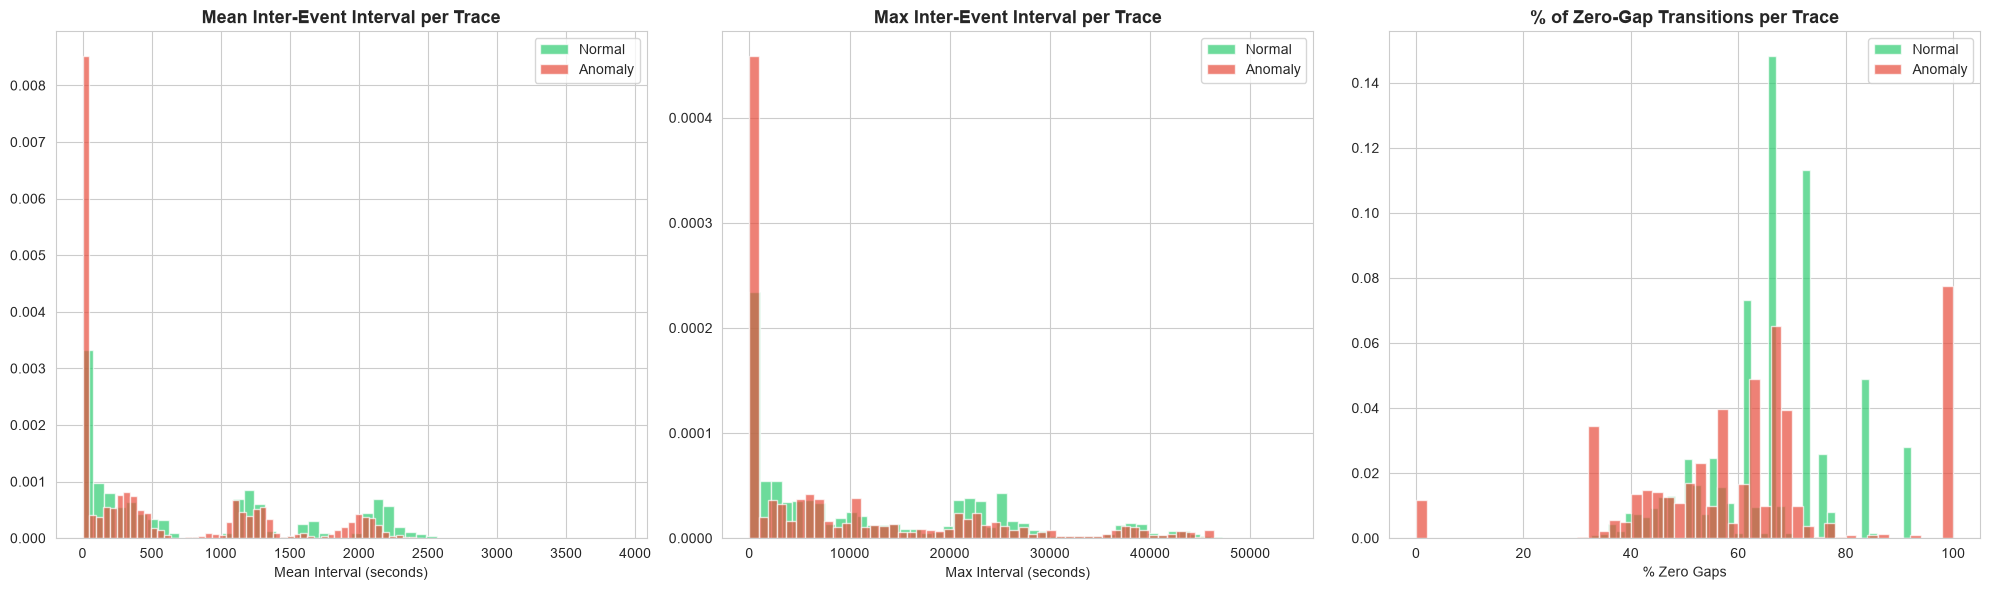

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Mean interval per trace
axes[0].hist(normal_traces['mean_interval'], bins=50, alpha=0.7, color='#2ecc71', 
             label='Normal', density=True)
axes[0].hist(anomaly_traces['mean_interval'], bins=50, alpha=0.7, color='#e74c3c', 
             label='Anomaly', density=True)
axes[0].set_title('Mean Inter-Event Interval per Trace', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Interval (seconds)')
axes[0].legend()

# 2. Max interval per trace (the biggest gap — where did it stall?)
axes[1].hist(normal_traces['max_interval'], bins=50, alpha=0.7, color='#2ecc71', 
             label='Normal', density=True)
axes[1].hist(anomaly_traces['max_interval'], bins=50, alpha=0.7, color='#e74c3c', 
             label='Anomaly', density=True)
axes[1].set_title('Max Inter-Event Interval per Trace', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Max Interval (seconds)')
axes[1].legend()

# 3. % of zero-gap events (instantaneous transitions)
axes[2].hist(normal_traces['zero_pct'], bins=50, alpha=0.7, color='#2ecc71', 
             label='Normal', density=True)
axes[2].hist(anomaly_traces['zero_pct'], bins=50, alpha=0.7, color='#e74c3c', 
             label='Anomaly', density=True)
axes[2].set_title('% of Zero-Gap Transitions per Trace', fontsize=13, fontweight='bold')
axes[2].set_xlabel('% Zero Gaps')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/interval_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 3: When Do Failures Happen? (Raw Log Timeline)

Now we go to the raw `HDFS.log` file. Each line starts with a timestamp like `081109 203518`:
- `081109` = November 9, 2008
- `203518` = 20:35:18 (8:35 PM)

We'll parse these timestamps WITHOUT loading the entire 1.5GB file into memory. Instead we read line-by-line and only extract the timestamp + block ID. This is a critical skill for working with large log files.

**What we want to know**: Is there a time window where anomalies concentrate? Do failures correlate with high log volume (system under load)?


In [ ]:
import re
from tqdm import tqdm

# Load the anomaly block IDs for lookup
labels_df = pd.read_csv(os.path.join(DATA_DIR, "anomaly_label.csv"))
anomaly_blocks = set(labels_df[labels_df['Label'] == 'Anomaly']['BlockId'].values)
print(f"Loaded {len(anomaly_blocks):,} anomaly block IDs for lookup")

# Parse raw log — extract timestamp and block ID
# Format: "081109 203518 143 INFO dfs.DataNode$DataXceiver: ... blk_XXXXX ..."
block_pattern = re.compile(r'(blk_-?\d+)')

timestamps = []
is_anomaly_line = []

print("Parsing raw log timestamps (this takes 1-2 minutes for 11M lines)...")

with open(RAW_LOG, 'r') as f:
    for line in tqdm(f, total=11175630, desc="Parsing"):
        try:
            # Extract timestamp from first 13 chars: "081109 203518"
            ts_str = line[:13]
            ts = datetime.strptime(ts_str, "%y%m%d %H%M%S")
            
            # Check if this line mentions an anomaly block
            block_match = block_pattern.search(line)
            is_anom = False
            if block_match:
                block_id = block_match.group(1)
                is_anom = block_id in anomaly_blocks
            
            timestamps.append(ts)
            is_anomaly_line.append(is_anom)
        except:
            continue
print(f"\n Parsed {len(timestamps):,} log lines with timestamps")
print(f"   Lines mentioning anomaly blocks: {sum(is_anomaly_line):,}")
print(f"   Time range: {min(timestamps)} → {max(timestamps)}")


Loaded 16,838 anomaly block IDs for lookup
Parsing raw log timestamps (this takes 1-2 minutes for 11M lines)...


Parsing: 100%|█████████▉| 11175629/11175630 [02:00<00:00, 92372.09it/s] 



✅ Parsed 11,175,629 log lines with timestamps
   Lines mentioning anomaly blocks: 288,250
   Time range: 2008-11-09 20:35:18 → 2008-11-11 11:16:28


In [16]:
normal_traces.head(10)  # Show the first 10 rows of the normal traces DataFrame

,BlockId,Label,Type,Features,TimeInterval,Latency
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
3,blk_-9073992586687739851,Success,NaN,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50448
4,blk_7854771516489510256,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50583
5,blk_1717858812220360316,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 11.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0...",50458
6,blk_-2519617320378473615,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 9.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50523
7,blk_7063315473424667801,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E9,E26,E26,E11,E9,E26...","[1.0, 0.0, 0.0, 58.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50818
8,blk_8586544123689943463,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E11,E9,E9,E26,E26,E26...","[1.0, 0.0, 0.0, 36.0, 0.0, 1.0, 0.0, 0.0, 0.0,...",50795
9,blk_2765344736980045501,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E26,E11,E9,E26,E26...","[0.0, 0.0, 1.0, 28.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",50528
10,blk_-2900490557492272760,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 7.0, 44.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50440


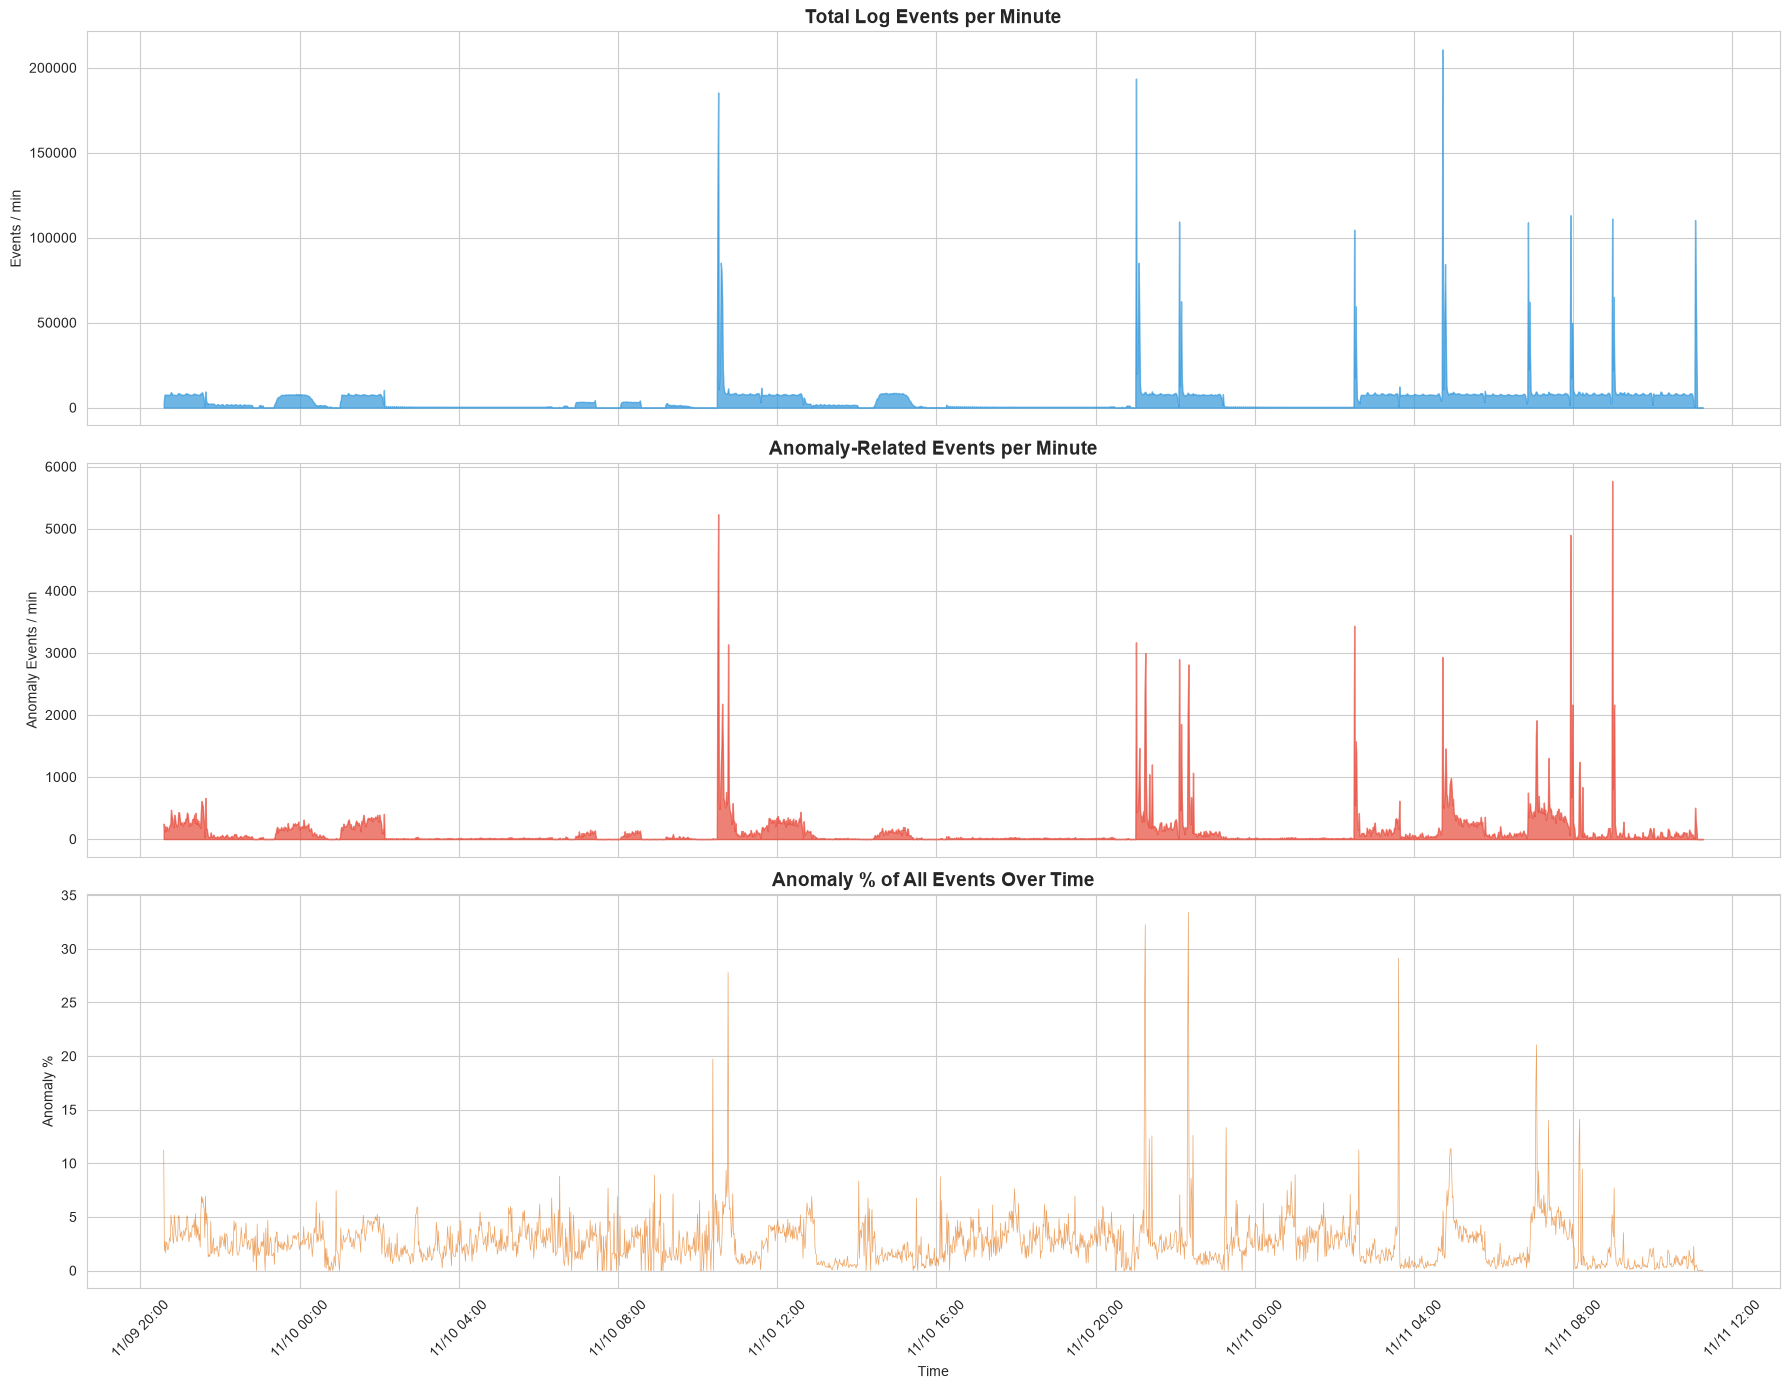


🔴 Top 10 minutes with highest anomaly event count:
   2008-11-11 08:59:00  — 5,770 anomaly events / 111,285 total (5.2%)
   2008-11-10 10:31:00  — 5,233 anomaly events / 185,420 total (2.8%)
   2008-11-11 07:56:00  — 4,899 anomaly events / 113,175 total (4.3%)
   2008-11-11 02:30:00  — 3,437 anomaly events / 104,684 total (3.3%)
   2008-11-10 10:30:00  — 3,367 anomaly events / 128,416 total (2.6%)
   2008-11-10 21:01:00  — 3,169 anomaly events / 193,604 total (1.6%)
   2008-11-10 10:46:00  — 3,136 anomaly events / 11,286 total (27.8%)
   2008-11-10 21:15:00  — 2,996 anomaly events / 9,288 total (32.3%)
   2008-11-11 04:43:00  — 2,931 anomaly events / 210,778 total (1.4%)
   2008-11-10 22:06:00  — 2,899 anomaly events / 109,471 total (2.6%)


In [19]:
# Create a DataFrame for temporal analysis
log_timeline = pd.DataFrame({
    'timestamp': timestamps,
    'is_anomaly': is_anomaly_line
})

# Bin by minute
log_timeline['minute'] = log_timeline['timestamp'].dt.floor('min')

# Count events per minute — total and anomaly-related
events_per_min = log_timeline.groupby('minute').agg(
    total_events=('timestamp', 'count'),
    anomaly_events=('is_anomaly', 'sum')
).reset_index()

events_per_min['anomaly_pct'] = (events_per_min['anomaly_events'] / 
                                  events_per_min['total_events'] * 100)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

# 1. Total log volume over time
axes[0].fill_between(events_per_min['minute'], events_per_min['total_events'], 
                      alpha=0.7, color='#3498db')
axes[0].set_title('Total Log Events per Minute', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Events / min')

# 2. Anomaly-related events over time
axes[1].fill_between(events_per_min['minute'], events_per_min['anomaly_events'], 
                      alpha=0.7, color='#e74c3c')
axes[1].set_title('Anomaly-Related Events per Minute', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Anomaly Events / min')

# 3. Anomaly percentage over time
axes[2].plot(events_per_min['minute'], events_per_min['anomaly_pct'], 
             color='#e67e22', linewidth=0.5, alpha=0.7)
axes[2].set_title('Anomaly % of All Events Over Time', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Anomaly %')
axes[2].set_xlabel('Time')

# Format x-axis
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../outputs/log_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# Print peak anomaly periods
print("\n🔴 Top 10 minutes with highest anomaly event count:")
top_anomaly_mins = events_per_min.nlargest(10, 'anomaly_events')
for _, row in top_anomaly_mins.iterrows():
    print(f"   {row['minute']}  — {int(row['anomaly_events']):,} anomaly events "
          f"/ {int(row['total_events']):,} total ({row['anomaly_pct']:.1f}%)")


## Step 4: Temporal Patterns — Hour-of-Day Analysis

Are there certain hours when the system is more prone to failures? In real cloud environments, workload patterns follow daily cycles — peak traffic during business hours, batch jobs at night, etc.


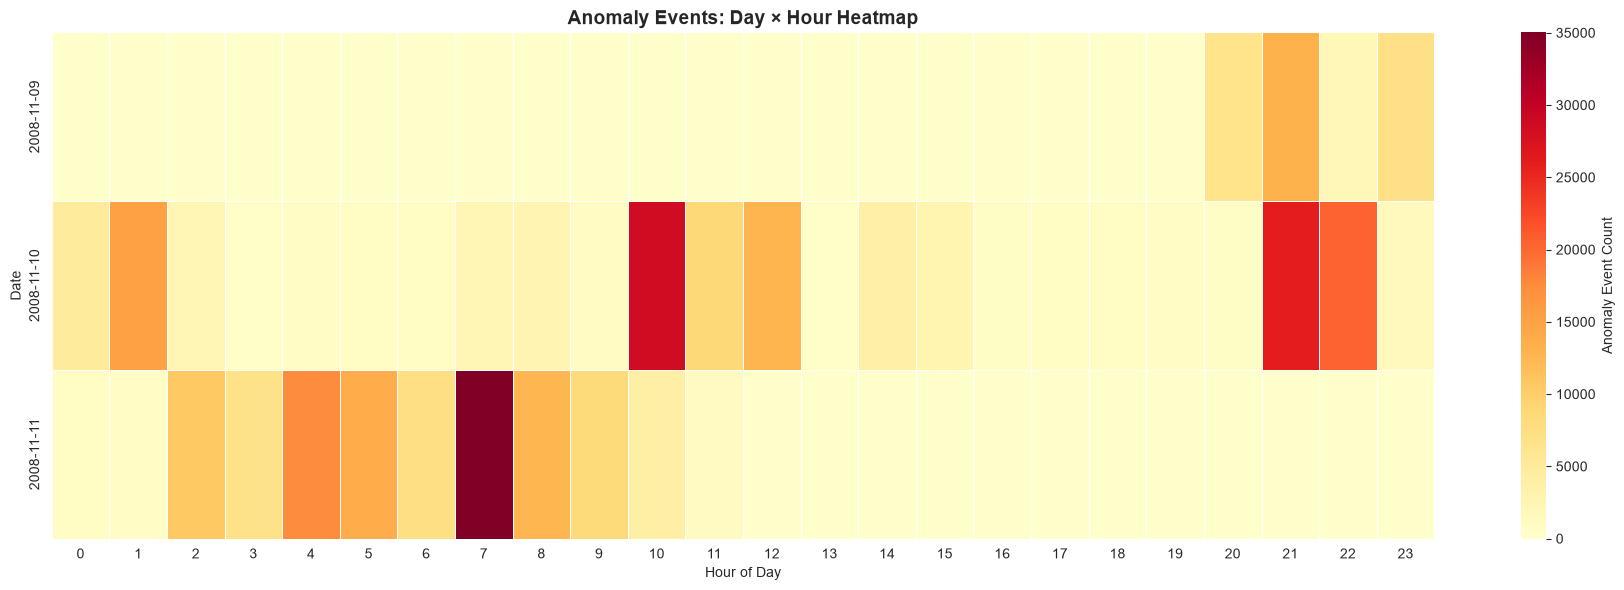

In [20]:
# Extract hour and day
log_timeline['hour'] = log_timeline['timestamp'].dt.hour
log_timeline['date'] = log_timeline['timestamp'].dt.date

# Heatmap: Day × Hour, colored by anomaly event count
anomaly_lines = log_timeline[log_timeline['is_anomaly'] == True]
heatmap_data = anomaly_lines.groupby(['date', 'hour']).size().reset_index(name='count')
heatmap_pivot = heatmap_data.pivot_table(index='date', columns='hour', 
                                          values='count', fill_value=0)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(heatmap_pivot, cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Anomaly Event Count'})
ax.set_title('Anomaly Events: Day × Hour Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Date')

plt.tight_layout()
plt.savefig('../outputs/anomaly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


##  Step 5: Burst Detection — When Do Anomalies Spike?

**Concept — Burst Detection**: A "burst" is a sudden spike in anomaly events that's significantly above the baseline. We detect bursts by:
1. Computing a rolling average (baseline)
2. Computing a rolling standard deviation
3. Flagging any minute where anomaly count > baseline + 2×std

This is a simple form of **anomaly detection on the anomaly rate itself** — meta-anomaly detection!


Detected 0 burst minutes out of 2322 total minutes


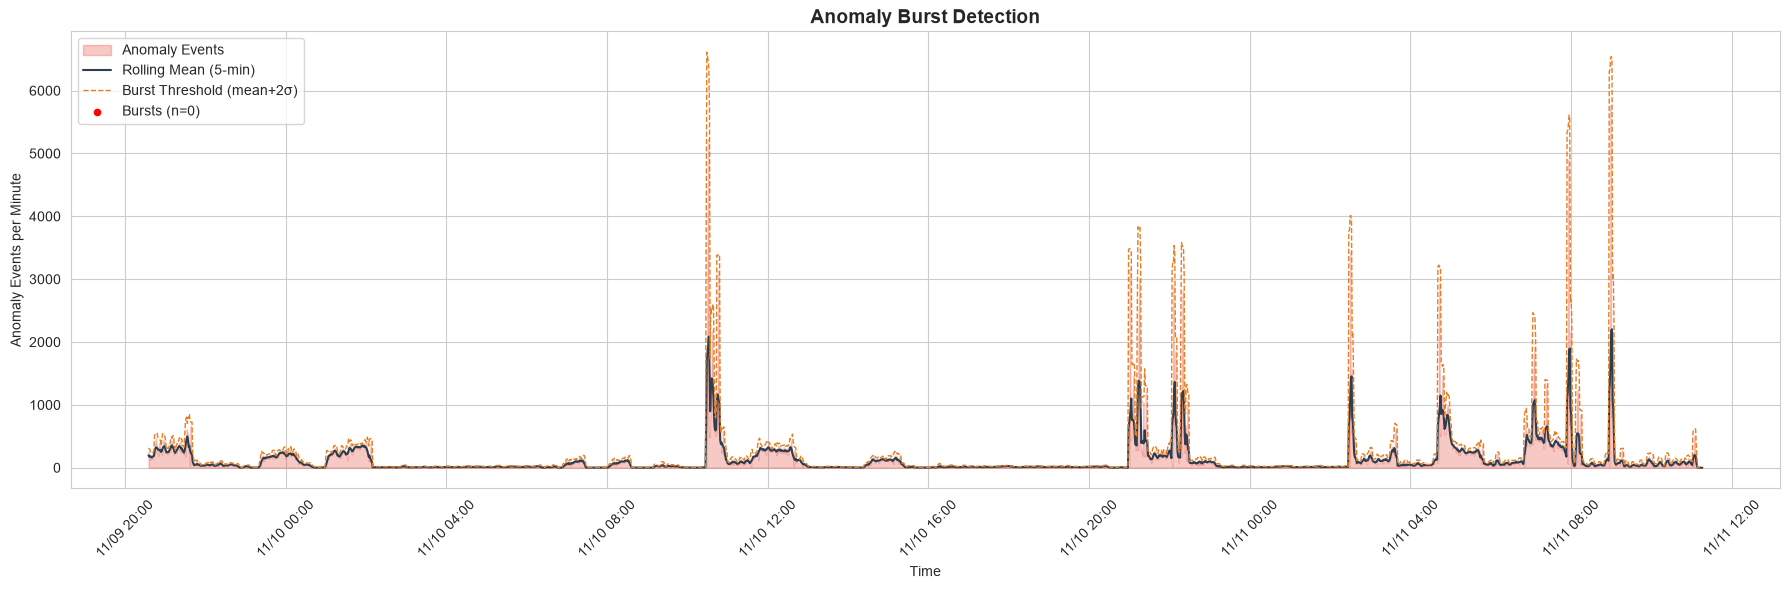

In [21]:
# Compute rolling statistics (5-minute window)
window = 5
events_per_min['rolling_mean'] = events_per_min['anomaly_events'].rolling(
    window=window, center=True, min_periods=1).mean()
events_per_min['rolling_std'] = events_per_min['anomaly_events'].rolling(
    window=window, center=True, min_periods=1).std().fillna(0)
events_per_min['upper_threshold'] = (events_per_min['rolling_mean'] + 
                                      2 * events_per_min['rolling_std'])

# Flag bursts
events_per_min['is_burst'] = (events_per_min['anomaly_events'] > 
                               events_per_min['upper_threshold'])

burst_count = events_per_min['is_burst'].sum()
print(f"Detected {burst_count} burst minutes out of {len(events_per_min)} total minutes")

# Visualize
fig, ax = plt.subplots(figsize=(18, 6))

ax.fill_between(events_per_min['minute'], events_per_min['anomaly_events'], 
                alpha=0.3, color='#e74c3c', label='Anomaly Events')
ax.plot(events_per_min['minute'], events_per_min['rolling_mean'], 
        color='#2c3e50', linewidth=1.5, label=f'Rolling Mean ({window}-min)')
ax.plot(events_per_min['minute'], events_per_min['upper_threshold'], 
        color='#e67e22', linewidth=1, linestyle='--', label='Burst Threshold (mean+2σ)')

# Highlight burst periods
burst_mins = events_per_min[events_per_min['is_burst']]
ax.scatter(burst_mins['minute'], burst_mins['anomaly_events'], 
           color='red', s=20, zorder=5, label=f'Bursts (n={burst_count})')

ax.set_title('Anomaly Burst Detection', fontsize=14, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Anomaly Events per Minute')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../outputs/burst_detection.png', dpi=150, bbox_inches='tight')
plt.show()


##  Step 6: Latency Correlations — What Makes Traces Slow?

Let's connect timing back to the event data. Does having more error events correlate with longer latency? Does sequence length predict latency? These correlations tell the CoT agent WHAT to blame when a trace is slow.


In [24]:
traces_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 575061 entries, 0 to 575060
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   BlockId        575061 non-null  str    
 1   Label          575061 non-null  str    
 2   Type           16838 non-null   float64
 3   Features       575061 non-null  str    
 4   TimeInterval   575061 non-null  str    
 5   Latency        575061 non-null  int64  
 6   intervals      575061 non-null  object 
 7   num_intervals  575061 non-null  int64  
 8   mean_interval  575061 non-null  float64
 9   max_interval   575061 non-null  float64
 10  std_interval   575061 non-null  float64
 11  zero_pct       575061 non-null  float64
dtypes: float64(5), int64(2), object(1), str(4)
memory usage: 52.6+ MB


In [23]:
traces_df.head(10)  # Show the first 10 rows of the traces DataFrame

,BlockId,Label,Type,Features,TimeInterval,Latency,intervals,num_intervals,mean_interval,max_interval,std_interval,zero_pct
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",268,14.186567,3703.0,225.770180,88.059701
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",21,181.047619,3044.0,649.220153,66.666667
2,blk_-3544583377289625738,Fail,21.0,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",3797,"[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",222,17.103604,3713.0,248.627028,89.639640
3,blk_-9073992586687739851,Success,NaN,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50448,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",21,2402.285714,49727.0,10582.327038,61.904762
4,blk_7854771516489510256,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50583,"[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",37,1367.108108,46034.0,7465.767935,40.540541
5,blk_1717858812220360316,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 11.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0...",50458,"[0.0, 0.0, 11.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0...",37,1363.729730,45977.0,7453.910041,35.135135
6,blk_-2519617320378473615,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 9.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50523,"[0.0, 1.0, 9.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",37,1365.486486,45965.0,7444.562840,32.432432
7,blk_7063315473424667801,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E9,E26,E26,E11,E9,E26...","[1.0, 0.0, 0.0, 58.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50818,"[1.0, 0.0, 0.0, 58.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",37,1373.459459,45955.0,7437.208150,35.135135
8,blk_8586544123689943463,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E11,E9,E9,E26,E26,E26...","[1.0, 0.0, 0.0, 36.0, 0.0, 1.0, 0.0, 0.0, 0.0,...",50795,"[1.0, 0.0, 0.0, 36.0, 0.0, 1.0, 0.0, 0.0, 0.0,...",37,1372.837838,46132.0,7478.644911,35.135135
9,blk_2765344736980045501,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E26,E11,E9,E26,E26...","[0.0, 0.0, 1.0, 28.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",50528,"[0.0, 0.0, 1.0, 28.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",37,1365.621622,46019.0,7460.892046,32.432432


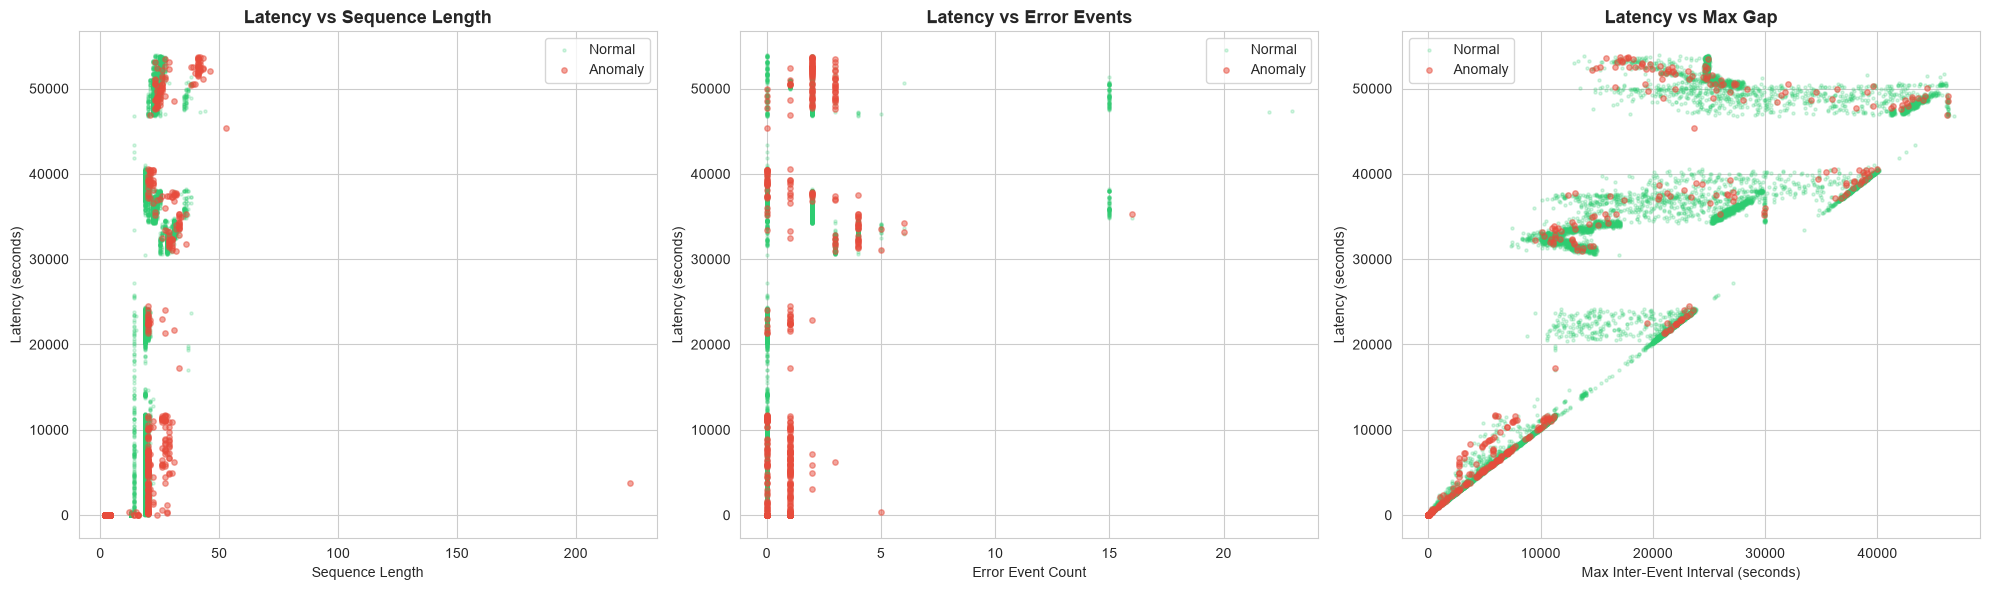


Correlation with Latency:
   seq_length           r = 0.619
   error_count          r = 0.518
   mean_interval        r = 0.976
   max_interval         r = 0.894


In [25]:
# Parse sequences (if not already loaded from NB03)
def parse_sequence(s):
    if not isinstance(s, str):
        return []

    s = s.strip()

    if s.startswith('[') and s.endswith(']'):
        s = s[1:-1]

    return [e.strip() for e in s.split(',') if e.strip()]


traces_df['sequence'] = traces_df['Features'].apply(parse_sequence)
traces_df['seq_length'] = traces_df['sequence'].str.len()
# Count error events per trace
error_events = {'E4', 'E7', 'E10', 'E12', 'E14', 'E17', 'E20', 'E29'}
traces_df['error_count'] = traces_df['sequence'].apply(
    lambda seq: sum(1 for e in seq if e in error_events))

# Scatter: latency vs sequence length, colored by label
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Sample for plotting speed
np.random.seed(42)
sample = traces_df.sample(min(20000, len(traces_df)))
normal_sample = sample[sample['Label'] == 'Success']
anomaly_sample = sample[sample['Label'] == 'Fail']

# 1. Latency vs Sequence Length
axes[0].scatter(normal_sample['seq_length'], normal_sample['Latency'], 
                alpha=0.2, s=5, c='#2ecc71', label='Normal')
axes[0].scatter(anomaly_sample['seq_length'], anomaly_sample['Latency'], 
                alpha=0.5, s=15, c='#e74c3c', label='Anomaly')
axes[0].set_xlabel('Sequence Length')
axes[0].set_ylabel('Latency (seconds)')
axes[0].set_title('Latency vs Sequence Length', fontsize=13, fontweight='bold')
axes[0].legend()

# 2. Latency vs Error Count
axes[1].scatter(normal_sample['error_count'], normal_sample['Latency'], 
                alpha=0.2, s=5, c='#2ecc71', label='Normal')
axes[1].scatter(anomaly_sample['error_count'], anomaly_sample['Latency'], 
                alpha=0.5, s=15, c='#e74c3c', label='Anomaly')
axes[1].set_xlabel('Error Event Count')
axes[1].set_ylabel('Latency (seconds)')
axes[1].set_title('Latency vs Error Events', fontsize=13, fontweight='bold')
axes[1].legend()

# 3. Latency vs Max Interval
axes[2].scatter(normal_sample['max_interval'], normal_sample['Latency'], 
                alpha=0.2, s=5, c='#2ecc71', label='Normal')
axes[2].scatter(anomaly_sample['max_interval'], anomaly_sample['Latency'], 
                alpha=0.5, s=15, c='#e74c3c', label='Anomaly')
axes[2].set_xlabel('Max Inter-Event Interval (seconds)')
axes[2].set_ylabel('Latency (seconds)')
axes[2].set_title('Latency vs Max Gap', fontsize=13, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/latency_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlations
print("\nCorrelation with Latency:")
for col in ['seq_length', 'error_count', 'mean_interval', 'max_interval']:
    corr = traces_df[col].corr(traces_df['Latency'])
    print(f"   {col:<20} r = {corr:.3f}")


In [26]:
import json

temporal_findings = {
    "latency_stats": {
        "normal_mean": float(n_lat.mean()),
        "normal_median": float(n_lat.median()),
        "anomaly_mean": float(a_lat.mean()),
        "anomaly_median": float(a_lat.median()),
    },
    "interval_stats": {
        "normal_mean_interval": float(normal_traces['mean_interval'].mean()),
        "anomaly_mean_interval": float(anomaly_traces['mean_interval'].mean()),
        "normal_max_interval": float(normal_traces['max_interval'].mean()),
        "anomaly_max_interval": float(anomaly_traces['max_interval'].mean()),
    },
    "burst_count": int(burst_count) if 'burst_count' in dir() else 0,
    "time_range": {
        "start": str(min(timestamps)),
        "end": str(max(timestamps)),
    }
}

output_path = '../data/temporal_analysis_findings.json'
with open(output_path, 'w') as f:
    json.dump(temporal_findings, f, indent=2)

print(f"✅ Saved temporal findings to {output_path}")


✅ Saved temporal findings to ../data/temporal_analysis_findings.json


In [28]:
!jupyter nbconvert --to html 04_temporal_analysis.ipynb 

[NbConvertApp] Converting notebook 04_temporal_analysis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1351546 bytes to 04_temporal_analysis.html


In [29]:
!jupyter nbconvert --to pdf 04_temporal_analysis.ipynb 

[NbConvertApp] Converting notebook 04_temporal_analysis.ipynb to pdf
[NbConvertApp] ERROR | Error while converting '04_temporal_analysis.ipynb'
Traceback (most recent call last):
  File "C:\Users\zahra\AppData\Local\Programs\Python\Python313\Lib\site-packages\nbconvert\nbconvertapp.py", line 487, in export_single_notebook
    output, resources = self.exporter.from_filename(
                        ~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        notebook_filename, resources=resources
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\zahra\AppData\Local\Programs\Python\Python313\Lib\site-packages\nbconvert\exporters\templateexporter.py", line 390, in from_filename
    return super().from_filename(filename, resources, **kw)  # type:ignore[return-value]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\zahra\AppData\Local\Programs\Python\Python313\Lib\site-packages\nbconvert\exporters\exporter.py", line 201, in from_filename
    return self.from_fi